In [184]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [185]:
df_train=pd.read_csv('train.csv')
df_test=pd.read_csv('test.csv')
df_weather=pd.read_csv('/content/weather-sfcsv.csv')

In [186]:
# parsing an XML file containing holiday data and converting it into a pandas DataFrame
import xml.etree.ElementTree as Xet

rows = []

xmlparse = Xet.parse('holidays.xml')
root = xmlparse.getroot()
for i in root:
    rows.append({"holiday_name": i.find("description").text, "date": i.find("date").text})

df_holidays = pd.DataFrame(rows)

In [187]:
#preparing a column to merge the datsets
df_train['date'] = pd.to_datetime(df_train['timestamp'], format='mixed', errors='coerce').dt.date
df_train

,ID,Lat,Lng,Bump,Distance(mi),Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Stop,Amenity,Side,Severity,timestamp,date
0,0,37.762150,-122.405660,False,0.044,False,False,False,False,False,False,False,True,R,2,2016-03-25 15:13:02,2016-03-25
1,1,37.719157,-122.448254,False,0.000,False,False,False,False,False,False,False,False,R,2,2020-05-05 19:23:00,2020-05-05
2,2,37.808498,-122.366852,False,0.000,False,False,False,False,False,False,True,False,R,3,2016-09-16 19:57:16,2016-09-16
3,3,37.785930,-122.391080,False,0.009,False,False,True,False,False,False,False,False,R,1,2020-03-29 19:48:43,2020-03-29
4,4,37.719141,-122.448457,False,0.000,False,False,False,False,False,False,False,False,R,2,2019-10-09 08:47:00,2019-10-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6402,6402,37.740630,-122.407930,False,0.368,False,False,False,False,False,False,False,False,R,3,2017-10-01 18:36:13,2017-10-01
6403,6403,37.752755,-122.402790,False,0.639,False,False,True,False,False,False,False,False,R,2,2018-10-23 07:40:27,2018-10-23
6404,6404,37.726304,-122.446015,False,0.000,False,False,True,False,False,False,False,False,R,2,2019-10-28 15:45:00,2019-10-28
6405,6405,37.808090,-122.367211,False,0.000,False,False,True,False,False,False,False,False,R,3,2019-05-04 13:45:31,2019-05-04


In [188]:
df_holidays['date'] = pd.to_datetime(df_holidays['date']).dt.date
df_holidays.head()

,holiday_name,date
0,New Year Day,2012-01-02
1,Martin Luther King Jr. Day,2012-01-16
2,Presidents Day (Washingtons Birthday),2012-02-20
3,Memorial Day,2012-05-28
4,Independence Day,2012-07-04


In [189]:
df_weather['date']=pd.to_datetime(df_weather[["Year", "Month", "Day"]])
df_weather['date'] = pd.to_datetime(df_weather['date']).dt.date
df_weather.describe()

,Year,Day,Month,Hour,Wind_Chill(F),Precipitation(in),Temperature(F),Humidity(%),Wind_Speed(mph),Visibility(mi)
count,6901.000000,6901.000000,6901.000000,6901.000000,3292.000000,3574.000000,6899.000000,6899.000000,6556.000000,6900.000000
mean,2018.293001,15.624837,6.775250,12.789886,59.762515,0.006444,59.905465,68.570952,10.813164,9.441851
std,1.390524,8.703753,3.567982,5.874155,9.338456,0.028822,7.977860,16.180126,6.406376,1.640513
min,2016.000000,1.000000,1.000000,0.000000,31.100000,0.000000,36.000000,10.000000,0.000000,0.000000
25%,2017.000000,8.000000,4.000000,8.000000,54.000000,0.000000,54.000000,59.000000,5.800000,10.000000
50%,2019.000000,15.000000,7.000000,14.000000,59.000000,0.000000,59.000000,70.000000,10.000000,10.000000
75%,2020.000000,23.000000,10.000000,17.000000,66.000000,0.000000,64.900000,80.000000,15.000000,10.000000
max,2020.000000,31.000000,12.000000,23.000000,98.000000,0.490000,98.100000,100.000000,40.300000,10.000000


In [190]:
#checking null values in weather dataframe
df_weather.isnull().sum()

,0
Year,0
Day,0
Month,0
Hour,0
Weather_Condition,1
Wind_Chill(F),3609
Precipitation(in),3327
Temperature(F),2
Humidity(%),2
Wind_Speed(mph),345


In [191]:
#checking valuecounts in weather dataframe
for col in df_weather.columns:
  print(df_weather[col].value_counts())

Year
2019    1750
2020    1741
2018    1205
2017    1200
2016    1005
Name: count, dtype: int64
Day
20    262
6     259
12    253
22    245
14    244
10    243
1     240
11    240
9     237
30    236
13    236
5     235
17    231
8     227
27    227
18    227
7     226
19    226
16    225
23    224
15    215
4     215
28    214
24    213
29    205
21    197
25    197
2     196
3     195
26    195
31    116
Name: count, dtype: int64
Month
12    742
10    673
11    649
9     625
5     611
4     552
2     549
1     549
3     546
6     543
8     518
7     344
Name: count, dtype: int64
Hour
15    479
18    473
17    473
14    452
16    438
9     384
8     348
19    342
7     337
13    333
12    305
11    286
6     281
10    267
20    243
21    217
23    204
22    195
5     186
2     165
1     133
0     132
4     123
3     105
Name: count, dtype: int64
Weather_Condition
Partly Cloudy                   1580
Mostly Cloudy                   1445
Fair                            1279
Overcast    

In [192]:
df_weather.drop(['Precipitation(in)', 'Wind_Chill(F)', 'Selected', 'Hour'], axis=1, inplace=True)
df_weather

,Year,Day,Month,Weather_Condition,Temperature(F),Humidity(%),Wind_Speed(mph),Visibility(mi),date
0,2020,27,7,Fair,64.0,70.0,20.0,10.0,2020-07-27
1,2017,30,9,Partly Cloudy,71.1,57.0,9.2,10.0,2017-09-30
2,2017,27,6,Overcast,57.9,87.0,15.0,9.0,2017-06-27
3,2016,7,9,Clear,66.9,73.0,4.6,10.0,2016-09-07
4,2019,19,10,Fair,52.0,89.0,0.0,9.0,2019-10-19
...,...,...,...,...,...,...,...,...,...
6896,2018,23,1,Clear,51.1,80.0,3.5,10.0,2018-01-23
6897,2019,16,6,Cloudy,56.0,80.0,9.0,9.0,2019-06-16
6898,2017,7,2,Rain,61.0,90.0,32.2,7.0,2017-02-07
6899,2016,22,4,Mostly Cloudy,61.0,67.0,21.9,10.0,2016-04-22


In [193]:
#checking unique values in Date column
df_weather['date'].nunique()

1592

In [194]:
#Dropping duplicates in date column
df_weather.drop_duplicates(subset='date', inplace=True)
df_weather

,Year,Day,Month,Weather_Condition,Temperature(F),Humidity(%),Wind_Speed(mph),Visibility(mi),date
0,2020,27,7,Fair,64.0,70.0,20.0,10.0,2020-07-27
1,2017,30,9,Partly Cloudy,71.1,57.0,9.2,10.0,2017-09-30
2,2017,27,6,Overcast,57.9,87.0,15.0,9.0,2017-06-27
3,2016,7,9,Clear,66.9,73.0,4.6,10.0,2016-09-07
4,2019,19,10,Fair,52.0,89.0,0.0,9.0,2019-10-19
...,...,...,...,...,...,...,...,...,...
6806,2017,17,10,Clear,62.1,39.0,NaN,10.0,2017-10-17
6815,2017,23,9,Clear,62.1,75.0,5.8,10.0,2017-09-23
6826,2017,15,8,Mostly Cloudy,61.0,81.0,15.0,10.0,2017-08-15
6838,2020,5,9,Partly Cloudy,82.0,29.0,17.0,10.0,2020-09-05


In [195]:
# grouping by both 'date' and 'Weather_Condition'
df_weather = df_weather.groupby(['date', 'Weather_Condition'], as_index=False)[['Year', 'Day', 'Month', 'Wind_Speed(mph)', 'Visibility(mi)', 'Temperature(F)']].mean()


In [196]:
#CONVERTING holidays into csv file
df_holidays.to_csv("holidays.csv", index =False)

In [197]:
#Merging train and holidays dataframe
df_train=df_train.merge(df_holidays, on='date', how='left')
df_train

,ID,Lat,Lng,Bump,Distance(mi),Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Stop,Amenity,Side,Severity,timestamp,date,holiday_name
0,0,37.762150,-122.405660,False,0.044,False,False,False,False,False,False,False,True,R,2,2016-03-25 15:13:02,2016-03-25,NaN
1,1,37.719157,-122.448254,False,0.000,False,False,False,False,False,False,False,False,R,2,2020-05-05 19:23:00,2020-05-05,NaN
2,2,37.808498,-122.366852,False,0.000,False,False,False,False,False,False,True,False,R,3,2016-09-16 19:57:16,2016-09-16,NaN
3,3,37.785930,-122.391080,False,0.009,False,False,True,False,False,False,False,False,R,1,2020-03-29 19:48:43,2020-03-29,NaN
4,4,37.719141,-122.448457,False,0.000,False,False,False,False,False,False,False,False,R,2,2019-10-09 08:47:00,2019-10-09,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6402,6402,37.740630,-122.407930,False,0.368,False,False,False,False,False,False,False,False,R,3,2017-10-01 18:36:13,2017-10-01,NaN
6403,6403,37.752755,-122.402790,False,0.639,False,False,True,False,False,False,False,False,R,2,2018-10-23 07:40:27,2018-10-23,NaN
6404,6404,37.726304,-122.446015,False,0.000,False,False,True,False,False,False,False,False,R,2,2019-10-28 15:45:00,2019-10-28,NaN
6405,6405,37.808090,-122.367211,False,0.000,False,False,True,False,False,False,False,False,R,3,2019-05-04 13:45:31,2019-05-04,NaN


In [198]:
#Checking value_counts for holiday_name
df_train['holiday_name'].value_counts()

,count
holiday_name,
Presidents Day (Washingtons Birthday),23
Christmas Day,19
Thanksgiving Day,19
Veterans Day,18
Columbus Day,18
Labor Day,14
Independence Day,12
New Year Day,10
Martin Luther King Jr. Day,9


In [199]:
#Merging train with weather
df_train=df_train.merge(df_weather, on='date', how='left')
df_train

,ID,Lat,Lng,Bump,Distance(mi),Crossing,Give_Way,Junction,No_Exit,Railway,...,timestamp,date,holiday_name,Weather_Condition,Year,Day,Month,Wind_Speed(mph),Visibility(mi),Temperature(F)
0,0,37.762150,-122.405660,False,0.044,False,False,False,False,False,...,2016-03-25 15:13:02,2016-03-25,NaN,Scattered Clouds,2016.0,25.0,3.0,13.8,10.0,64.9
1,1,37.719157,-122.448254,False,0.000,False,False,False,False,False,...,2020-05-05 19:23:00,2020-05-05,NaN,Fair,2020.0,5.0,5.0,17.0,10.0,67.0
2,2,37.808498,-122.366852,False,0.000,False,False,False,False,False,...,2016-09-16 19:57:16,2016-09-16,NaN,Partly Cloudy,2016.0,16.0,9.0,21.9,10.0,64.0
3,3,37.785930,-122.391080,False,0.009,False,False,True,False,False,...,2020-03-29 19:48:43,2020-03-29,NaN,Cloudy,2020.0,29.0,3.0,6.0,10.0,55.0
4,4,37.719141,-122.448457,False,0.000,False,False,False,False,False,...,2019-10-09 08:47:00,2019-10-09,NaN,Fair,2019.0,9.0,10.0,14.0,10.0,69.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6402,6402,37.740630,-122.407930,False,0.368,False,False,False,False,False,...,2017-10-01 18:36:13,2017-10-01,NaN,Scattered Clouds,2017.0,1.0,10.0,17.3,10.0,61.0
6403,6403,37.752755,-122.402790,False,0.639,False,False,True,False,False,...,2018-10-23 07:40:27,2018-10-23,NaN,Mostly Cloudy,2018.0,23.0,10.0,5.8,10.0,55.9
6404,6404,37.726304,-122.446015,False,0.000,False,False,True,False,False,...,2019-10-28 15:45:00,2019-10-28,NaN,Fair,2019.0,28.0,10.0,10.0,10.0,55.0
6405,6405,37.808090,-122.367211,False,0.000,False,False,True,False,False,...,2019-05-04 13:45:31,2019-05-04,NaN,Fair,2019.0,4.0,5.0,13.0,10.0,63.0


In [200]:
#filling the nulls with No holiday

df_train['holiday_name'].fillna('No Holidays',inplace=True)
#x = set(df_holidays['holiday_name'])
#df_train['holiday_name'].replace(x,'Holidays',inplace=True)

/tmp/ipykernel_248/3159486101.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['holiday_name'].fillna('No Holidays',inplace=True)


In [201]:
#filling Null values with mean
df_train['Wind_Speed(mph)'].fillna(df_train['Wind_Speed(mph)'].mean(),inplace=True)
df_train['Temperature(F)'].fillna(df_train['Temperature(F)'].mean(),inplace=True)


/tmp/ipykernel_248/2237782547.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Wind_Speed(mph)'].fillna(df_train['Wind_Speed(mph)'].mean(),inplace=True)
/tmp/ipykernel_248/2237782547.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].m

In [202]:
df_train.isnull().sum()

,0
ID,0
Lat,0
Lng,0
Bump,0
Distance(mi),0
Crossing,0
Give_Way,0
Junction,0
No_Exit,0
Railway,0


In [203]:
#get the is_weekdays and is_weekend and hour
df_train['timestamp'] = pd.to_datetime(df_train['timestamp'], format='mixed')
df_train['is_weekend'] = df_train['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
df_train['hour'] = df_train['timestamp'].dt.hour
df_train

,ID,Lat,Lng,Bump,Distance(mi),Crossing,Give_Way,Junction,No_Exit,Railway,...,holiday_name,Weather_Condition,Year,Day,Month,Wind_Speed(mph),Visibility(mi),Temperature(F),is_weekend,hour
0,0,37.762150,-122.405660,False,0.044,False,False,False,False,False,...,No Holidays,Scattered Clouds,2016.0,25.0,3.0,13.8,10.0,64.9,0,15
1,1,37.719157,-122.448254,False,0.000,False,False,False,False,False,...,No Holidays,Fair,2020.0,5.0,5.0,17.0,10.0,67.0,0,19
2,2,37.808498,-122.366852,False,0.000,False,False,False,False,False,...,No Holidays,Partly Cloudy,2016.0,16.0,9.0,21.9,10.0,64.0,0,19
3,3,37.785930,-122.391080,False,0.009,False,False,True,False,False,...,No Holidays,Cloudy,2020.0,29.0,3.0,6.0,10.0,55.0,1,19
4,4,37.719141,-122.448457,False,0.000,False,False,False,False,False,...,No Holidays,Fair,2019.0,9.0,10.0,14.0,10.0,69.0,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6402,6402,37.740630,-122.407930,False,0.368,False,False,False,False,False,...,No Holidays,Scattered Clouds,2017.0,1.0,10.0,17.3,10.0,61.0,1,18
6403,6403,37.752755,-122.402790,False,0.639,False,False,True,False,False,...,No Holidays,Mostly Cloudy,2018.0,23.0,10.0,5.8,10.0,55.9,0,7
6404,6404,37.726304,-122.446015,False,0.000,False,False,True,False,False,...,No Holidays,Fair,2019.0,28.0,10.0,10.0,10.0,55.0,0,15
6405,6405,37.808090,-122.367211,False,0.000,False,False,True,False,False,...,No Holidays,Fair,2019.0,4.0,5.0,13.0,10.0,63.0,1,13


In [204]:
#binning the Weather conditions
df_train['Weather_Condition']=df_train['Weather_Condition'].replace(['Partly Cloudy','Mostly Cloudy','Cloudy','Scattered Clouds','Cloudy / Windy','Mostly Cloudy / Windy','Partly Cloudy / Windy', 'Overcast'], 'Cloudy')
df_train['Weather_Condition']=df_train['Weather_Condition'].replace(['Light Rain','Rain','Heavy Rain','Light Rain / Windy'], 'Rain')
df_train['Weather_Condition']=df_train['Weather_Condition'].replace(['Haze','Fog','Shallow Fog','Mist','Smoke'], 'Fog')
df_train['Weather_Condition']=df_train['Weather_Condition'].replace('Fair / Windy', 'Fair')
df_train['Weather_Condition'].value_counts()

,count
Weather_Condition,
Cloudy,4095
Fair,1388
Rain,391
Clear,378
Fog,155


In [205]:
for col in df_train.columns:
  print(df_train[col].value_counts())

ID
6406    1
0       1
1       1
2       1
3       1
       ..
11      1
10      1
9       1
8       1
7       1
Name: count, Length: 6407, dtype: int64
Lat
37.808498    265
37.752502    106
37.808110     94
37.808253     89
37.807710     74
            ... 
37.782555      1
37.725774      1
37.809855      1
37.767426      1
37.733160      1
Name: count, Length: 2061, dtype: int64
Lng
-122.366852    269
-122.367190     94
-122.366974     92
-122.367640     74
-122.403008     63
              ... 
-122.394837      1
-122.367387      1
-122.367073      1
-122.402702      1
-122.402481      1
Name: count, Length: 1937, dtype: int64
Bump
False    6407
Name: count, dtype: int64
Distance(mi)
0.000    3923
0.010     499
0.037     158
0.420      40
0.208      35
         ... 
0.650       1
0.597       1
0.418       1
0.760       1
1.250       1
Name: count, Length: 579, dtype: int64
Crossing
False    5879
True      528
Name: count, dtype: int64
Give_Way
False    6404
True        3
Name: count,

In [206]:
df_train.drop(['ID','Bump','Give_Way','Roundabout','No_Exit','Year','Month','Day','date','timestamp'], axis=1, inplace=True)
df_train

,Lat,Lng,Distance(mi),Crossing,Junction,Railway,Stop,Amenity,Side,Severity,holiday_name,Weather_Condition,Wind_Speed(mph),Visibility(mi),Temperature(F),is_weekend,hour
0,37.762150,-122.405660,0.044,False,False,False,False,True,R,2,No Holidays,Cloudy,13.8,10.0,64.9,0,15
1,37.719157,-122.448254,0.000,False,False,False,False,False,R,2,No Holidays,Fair,17.0,10.0,67.0,0,19
2,37.808498,-122.366852,0.000,False,False,False,True,False,R,3,No Holidays,Cloudy,21.9,10.0,64.0,0,19
3,37.785930,-122.391080,0.009,False,True,False,False,False,R,1,No Holidays,Cloudy,6.0,10.0,55.0,1,19
4,37.719141,-122.448457,0.000,False,False,False,False,False,R,2,No Holidays,Fair,14.0,10.0,69.0,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6402,37.740630,-122.407930,0.368,False,False,False,False,False,R,3,No Holidays,Cloudy,17.3,10.0,61.0,1,18
6403,37.752755,-122.402790,0.639,False,True,False,False,False,R,2,No Holidays,Cloudy,5.8,10.0,55.9,0,7
6404,37.726304,-122.446015,0.000,False,True,False,False,False,R,2,No Holidays,Fair,10.0,10.0,55.0,0,15
6405,37.808090,-122.367211,0.000,False,True,False,False,False,R,3,No Holidays,Fair,13.0,10.0,63.0,1,13


In [207]:
df_train.to_csv('train_data.csv', index=False)


In [208]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6407 entries, 0 to 6406
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Lat                6407 non-null   float64
 1   Lng                6407 non-null   float64
 2   Distance(mi)       6407 non-null   float64
 3   Crossing           6407 non-null   bool   
 4   Junction           6407 non-null   bool   
 5   Railway            6407 non-null   bool   
 6   Stop               6407 non-null   bool   
 7   Amenity            6407 non-null   bool   
 8   Side               6407 non-null   object 
 9   Severity           6407 non-null   int64  
 10  holiday_name       6407 non-null   object 
 11  Weather_Condition  6407 non-null   object 
 12  Wind_Speed(mph)    6407 non-null   float64
 13  Visibility(mi)     6407 non-null   float64
 14  Temperature(F)     6407 non-null   float64
 15  is_weekend         6407 non-null   int64  
 16  hour               6407 

In [209]:
df_train['Severity'].value_counts()

,count
Severity,
2,4346
3,1855
1,129
4,77


**Plots**


How do road features such as bumps, crossings, junctions, and the presence of stop signs or traffic signals influence crash severity?

<Axes: xlabel='Crossing', ylabel='count'>

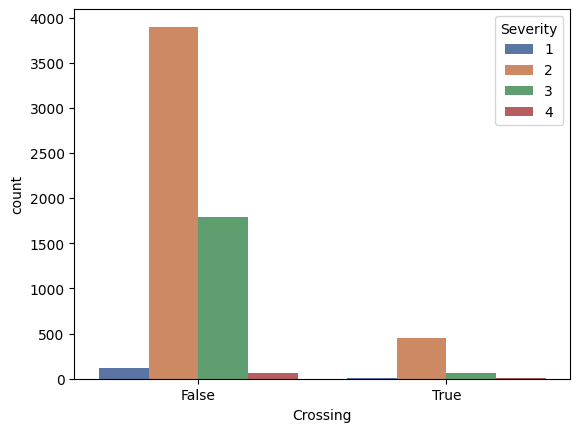

In [210]:
sns.countplot(x='Crossing',hue='Severity',data=df_train, palette='deep')

<Axes: xlabel='Junction', ylabel='count'>

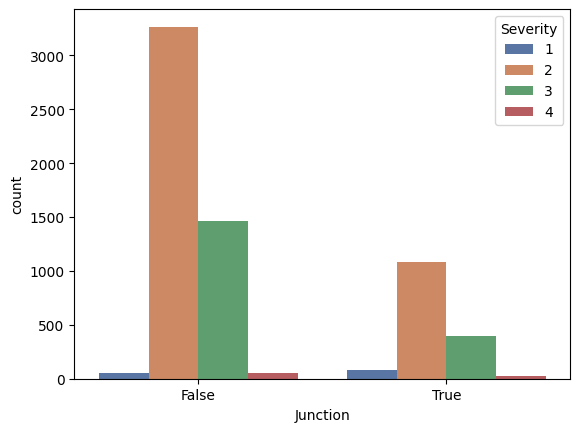

In [211]:
sns.countplot(x='Junction',hue='Severity',data=df_train, palette='deep')

<Axes: xlabel='Stop', ylabel='Count'>

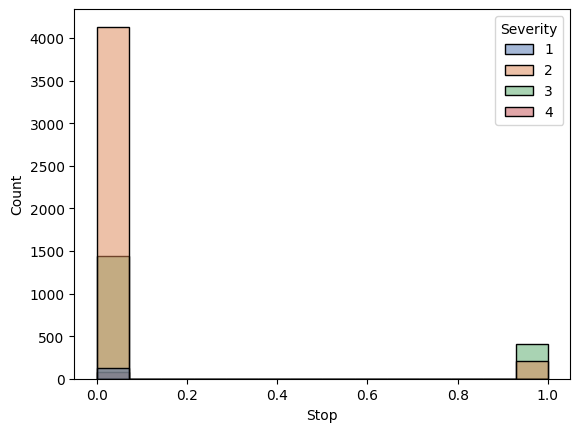

In [212]:
sns.histplot(x='Stop',hue='Severity',data=df_train, palette='deep')

<Axes: xlabel='Railway', ylabel='count'>

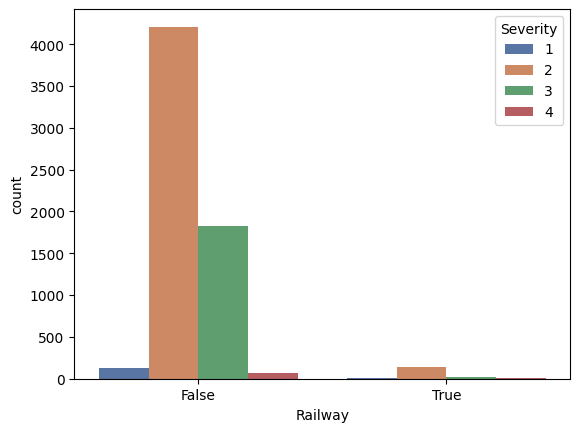

In [213]:
sns.countplot(x='Railway',hue='Severity',data=df_train, palette='deep')

<Axes: xlabel='Side', ylabel='count'>

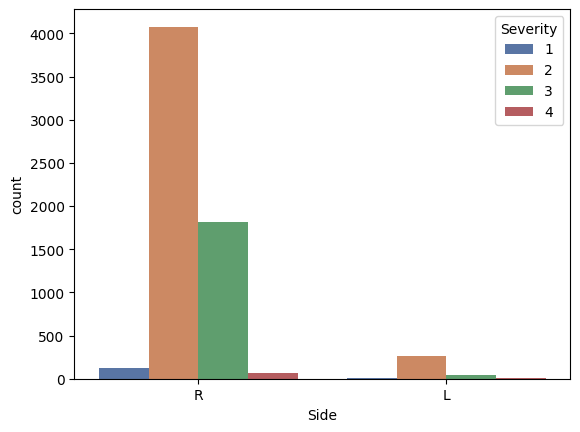

In [214]:
sns.countplot(x='Side',hue='Severity',data=df_train,palette='deep')


**What is the relationship between traffic congestion levels (as indicated by 'Distance') and the severity of crashes?**

/tmp/ipykernel_248/2859923153.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Distance(mi)',y='Severity',data=df_train, palette='deep')


<Axes: xlabel='Distance(mi)', ylabel='Severity'>

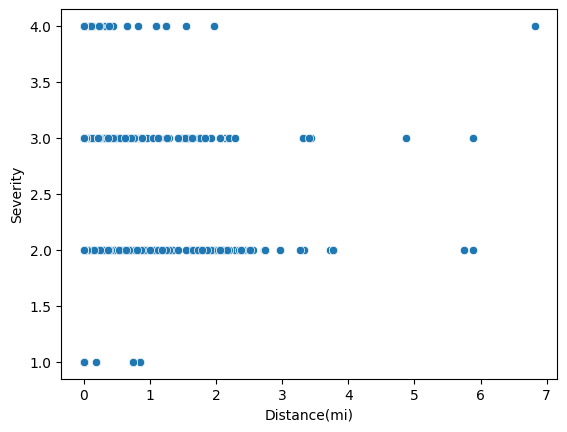

In [215]:
sns.scatterplot(x='Distance(mi)',y='Severity',data=df_train, palette='deep')


How do varying environmental conditions affect the outcomes of these crashes?

<Axes: xlabel='Temperature(F)', ylabel='Count'>

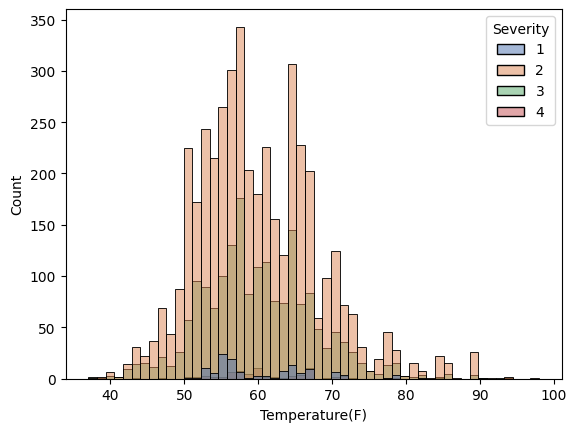

In [216]:
sns.histplot(x='Temperature(F)',hue='Severity',data=df_train, palette='deep')

<Axes: xlabel='Wind_Speed(mph)', ylabel='Count'>

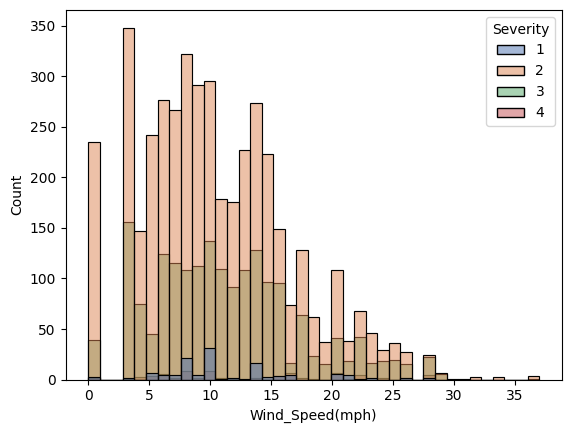

In [217]:
sns.histplot(x='Wind_Speed(mph)',hue='Severity',data=df_train, palette='deep')

<Axes: xlabel='Visibility(mi)', ylabel='Count'>

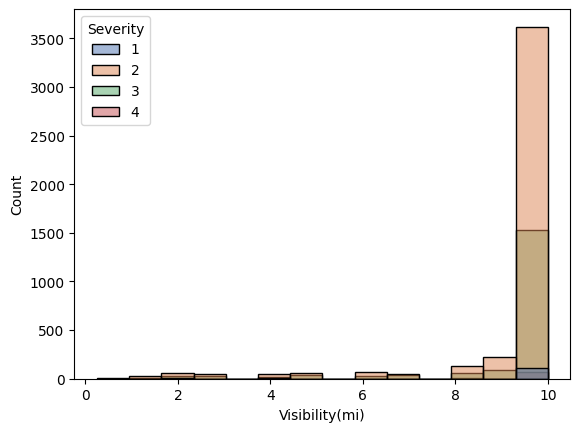

In [218]:
sns.histplot(x='Visibility(mi)',hue='Severity',data=df_train, palette='deep')

<Axes: xlabel='Weather_Condition', ylabel='Count'>

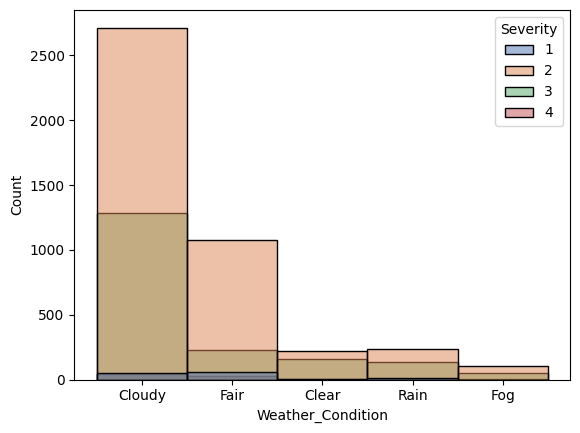

In [219]:
sns.histplot(x='Weather_Condition',hue='Severity',data=df_train, palette='deep')

Are there specific times of day or particular days (including holidays) that are more prone to severe crashes?

<Axes: xlabel='is_weekend', ylabel='Count'>

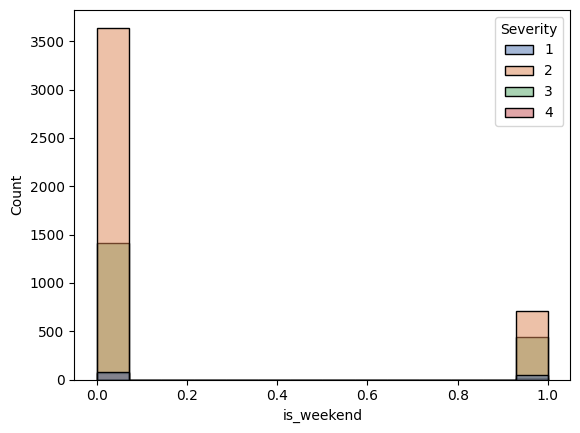

In [220]:
sns.histplot(x='is_weekend',hue='Severity',data=df_train, palette='deep')

<Axes: xlabel='hour', ylabel='Count'>

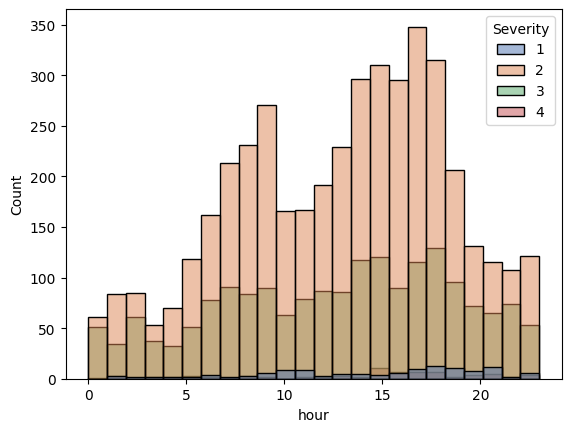

In [221]:
sns.histplot(x='hour',hue='Severity',data=df_train, palette='deep')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'No Holidays'),
  Text(1, 0, 'Christmas Day'),
  Text(2, 0, 'Presidents Day (Washingtons Birthday)'),
  Text(3, 0, 'New Year Day'),
  Text(4, 0, 'Martin Luther King Jr. Day'),
  Text(5, 0, 'Memorial Day'),
  Text(6, 0, 'Veterans Day'),
  Text(7, 0, 'Labor Day'),
  Text(8, 0, 'Columbus Day'),
  Text(9, 0, 'Independence Day'),
  Text(10, 0, 'Thanksgiving Day')])

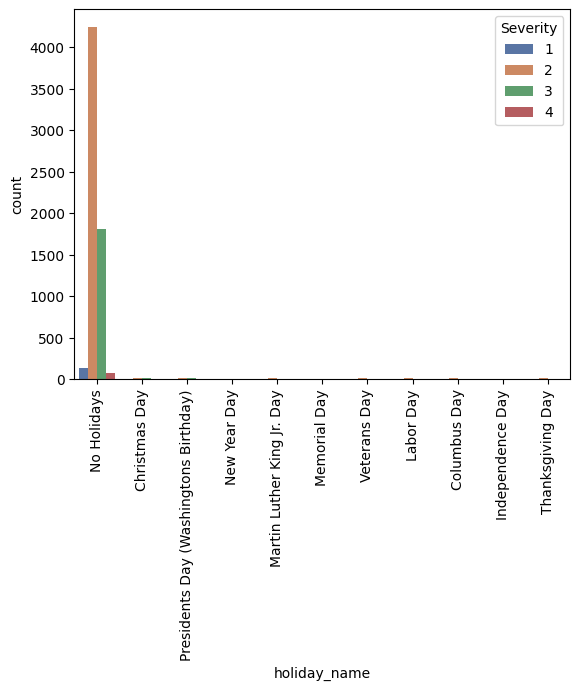

In [222]:
sns.countplot(x='holiday_name',hue='Severity',data=df_train, palette='deep')
plt.xticks(rotation=90)

**Feature Importance**

**Encoding**

In [223]:
#Selecting categorical columns
categorical_columns = ['Side', 'holiday_name', 'Weather_Condition']
df_train[categorical_columns]

,Side,holiday_name,Weather_Condition
0,R,No Holidays,Cloudy
1,R,No Holidays,Fair
2,R,No Holidays,Cloudy
3,R,No Holidays,Cloudy
4,R,No Holidays,Fair
...,...,...,...
6402,R,No Holidays,Cloudy
6403,R,No Holidays,Cloudy
6404,R,No Holidays,Fair
6405,R,No Holidays,Fair


In [224]:
from sklearn.preprocessing import OneHotEncoder

# Create a OneHotEncoder instance
onehot_encoder = OneHotEncoder(sparse_output=False, dtype=float, handle_unknown='ignore')

# Fit and transform the categorical columns
encoded_data = onehot_encoder.fit_transform(df_train[categorical_columns])

# Convert the result back to a DataFrame
encoded_columns = onehot_encoder.get_feature_names_out(categorical_columns)
encoded_df = pd.DataFrame(encoded_data, columns=encoded_columns)

# Drop the original categorical columns and concatenate the new encoded columns
df_train = df_train.drop(columns=categorical_columns)
df_train = pd.concat([df_train.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

In [225]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6407 entries, 0 to 6406
Data columns (total 32 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Lat                                                 6407 non-null   float64
 1   Lng                                                 6407 non-null   float64
 2   Distance(mi)                                        6407 non-null   float64
 3   Crossing                                            6407 non-null   bool   
 4   Junction                                            6407 non-null   bool   
 5   Railway                                             6407 non-null   bool   
 6   Stop                                                6407 non-null   bool   
 7   Amenity                                             6407 non-null   bool   
 8   Severity                                            6407 non-null   int64  
 9

**Model Training**

In [226]:
from sklearn.model_selection import train_test_split

train_set, val_df = train_test_split(df_train, test_size=0.2, random_state=42, stratify=df_train['Severity'])

X_train = train_set.drop(columns=['Severity'])
y_train = train_set['Severity']
X_val = val_df.drop(columns=['Severity'])
y_val = val_df['Severity']



In [227]:
# Fix class labels (for XGBoost)
y_train = y_train - 1
y_val = y_val - 1

In [228]:
# from imblearn.over_sampling import SMOTE
# from imblearn.under_sampling import RandomUnderSampler
# from collections import Counter

# # Step 1: Apply SMOTE to oversample the minority class
# smote = SMOTE(random_state=42)
# X_train, y_train = smote.fit_resample(X_train, y_train)

# # Step 2: Determine the desired number of samples for each class after undersampling
# # Let's assume you want to reduce the majority classes proportionally

# # You can examine the class distribution in y_train after SMOTE

# print("Class distribution after SMOTE:", Counter(y_train))

# # Based on the distribution, define the sampling strategy
# sampling_strategy = {
#     1: 500,  # Set the desired number of samples for class 1
#     2: 500,  # Set the desired number of samples for class 2
#     3: 500,  # Set the desired number of samples for class 3
#     4: 250   # Set the desired number of samples for class 4 (minority class)
# }

# # Step 3: Apply RandomUnderSampler using the dictionary strategy
# undersampler = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
# X_train, y_train = undersampler.fit_resample(X_train, y_train)

# # You can now check the new class distribution
# print("Class distribution after undersampling:", Counter(y_train))


In [229]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import f1_score
# from sklearn.metrics import accuracy_score
# from sklearn.metrics import classification_report


# classifier = RandomForestClassifier(max_depth=20, random_state=0)
# classifier = classifier.fit(X_train, y_train)
# print("The accuracy on validation ", (classifier.score(X_val, y_val)))
# f1_score(y_val, classifier.predict(X_val), average='macro')

In [230]:
# from sklearn.utils import compute_class_weight
# import numpy as np
# classes=np.unique(df_train['Severity'])
# class_weights = compute_class_weight(
#                                         class_weight="balanced",
#                                         classes=classes,
#                                         y=df_train['Severity']
#                                     )
# class_weights = dict(zip(np.unique(classes), class_weights)),
# class_weights


In [231]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
import xgboost
from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

classifiers = {
      'Logistic Regression': LogisticRegression(),
      'Decision Tree': DecisionTreeClassifier(),

       'Random Forest': RandomForestClassifier(random_state=0),

      'Support Vector Machine': SVC(),
      'K-Nearest Neighbors': KNeighborsClassifier(),
      'Naive Bayes': GaussianNB(),
      'Gradient Boosting': GradientBoostingClassifier(),
      'XGBoost': XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=0
)
      }

model_accuracy = []
model_f1=[]

for name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    f1=f1_score(y_val, y_pred, average='macro')

    model_accuracy.append({'Model': name, 'Accuracy': accuracy, 'F1':f1})


accuracy_df = pd.DataFrame(model_accuracy)
accuracy_df.sort_values(by='Accuracy', ascending=False, inplace=True)
accuracy_df


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,F1
2,Random Forest,0.836973,0.648987
7,XGBoost,0.836193,0.645458
6,Gradient Boosting,0.830733,0.541300
1,Decision Tree,0.788612,0.610764
0,Logistic Regression,0.719969,0.297144
3,Support Vector Machine,0.678627,0.202138
4,K-Nearest Neighbors,0.642746,0.356871
5,Naive Bayes,0.043682,0.044885


In [251]:
from sklearn.metrics import classification_report, confusion_matrix

# Assume y_true and y_pred are your true and predicted labels
report = classification_report(y_val, y_pred)
conf_matrix = confusion_matrix(y_val, y_pred)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.62      0.70        26
           1       0.85      0.93      0.89       870
           2       0.80      0.66      0.73       371
           3       0.43      0.20      0.27        15

    accuracy                           0.84      1282
   macro avg       0.72      0.60      0.65      1282
weighted avg       0.83      0.84      0.83      1282

Confusion Matrix:
 [[ 16   5   5   0]
 [  4 807  56   3]
 [  0 124 246   1]
 [  0  12   0   3]]


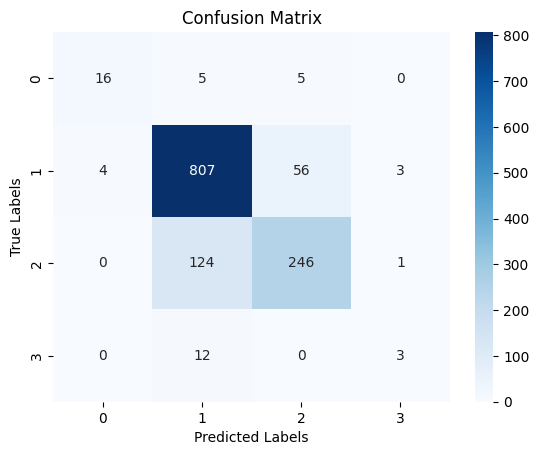

In [252]:
#draw confussion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

**Preparing Test Data**

In [234]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            1601 non-null   int64  
 1   Lat           1601 non-null   float64
 2   Lng           1601 non-null   float64
 3   Bump          1601 non-null   bool   
 4   Distance(mi)  1601 non-null   float64
 5   Crossing      1601 non-null   bool   
 6   Give_Way      1601 non-null   bool   
 7   Junction      1601 non-null   bool   
 8   No_Exit       1601 non-null   bool   
 9   Railway       1601 non-null   bool   
 10  Roundabout    1601 non-null   bool   
 11  Stop          1601 non-null   bool   
 12  Amenity       1601 non-null   bool   
 13  Side          1601 non-null   object 
 14  timestamp     1601 non-null   object 
dtypes: bool(9), float64(3), int64(1), object(2)
memory usage: 89.2+ KB


In [235]:
df_test['date'] = pd.to_datetime(df_test['timestamp'], format='mixed', errors='coerce').dt.date

In [236]:
df_test = pd.merge(df_test,df_holidays,on='date',how='left')
df_test = pd.merge(df_test,df_weather,on='date',how='left')

In [237]:
df_test['holiday_name'].fillna('No Holidays',inplace=True)

/tmp/ipykernel_248/1929492796.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['holiday_name'].fillna('No Holidays',inplace=True)


In [238]:
df_test['timestamp'] = pd.to_datetime(df_test['timestamp'], format='mixed')
df_test['is_weekend'] = df_test['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
df_test['hour'] = df_test['timestamp'].dt.hour
df_test

,ID,Lat,Lng,Bump,Distance(mi),Crossing,Give_Way,Junction,No_Exit,Railway,...,holiday_name,Weather_Condition,Year,Day,Month,Wind_Speed(mph),Visibility(mi),Temperature(F),is_weekend,hour
0,6407,37.786060,-122.390900,False,0.039,False,False,True,False,False,...,No Holidays,Clear,2016.0,4.0,4.0,NaN,10.0,55.9,0,19
1,6408,37.769609,-122.415057,False,0.202,False,False,False,False,False,...,No Holidays,Fair,2020.0,28.0,10.0,5.0,9.0,65.0,0,11
2,6409,37.807495,-122.476021,False,0.000,False,False,False,False,False,...,No Holidays,Mostly Cloudy,2019.0,9.0,9.0,18.0,10.0,58.0,0,7
3,6410,37.761818,-122.405869,False,0.000,False,False,True,False,False,...,No Holidays,Fair,2019.0,6.0,8.0,16.0,10.0,72.0,0,15
4,6411,37.732350,-122.414100,False,0.670,False,False,False,False,False,...,No Holidays,Partly Cloudy,2018.0,17.0,10.0,15.0,10.0,55.0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,8003,37.812973,-122.362335,False,4.460,False,False,False,False,False,...,No Holidays,Mostly Cloudy,2020.0,26.0,6.0,5.0,10.0,58.0,0,22
1597,8004,37.761818,-122.405861,False,0.010,False,False,True,False,False,...,No Holidays,Partly Cloudy,2016.0,3.0,12.0,NaN,10.0,46.0,1,7
1598,8005,37.732260,-122.431970,False,0.431,False,False,True,False,False,...,Presidents Day (Washingtons Birthday),Light Rain,2017.0,20.0,2.0,15.0,9.0,57.9,0,6
1599,8006,37.786782,-122.390126,False,0.000,True,False,False,False,False,...,No Holidays,Fair,2019.0,31.0,10.0,0.0,10.0,55.0,0,20


In [239]:
df_test.drop(['ID','Bump','Give_Way','Roundabout','No_Exit','Year','Month','Day','date','timestamp'], axis=1, inplace=True)
df_test


,Lat,Lng,Distance(mi),Crossing,Junction,Railway,Stop,Amenity,Side,holiday_name,Weather_Condition,Wind_Speed(mph),Visibility(mi),Temperature(F),is_weekend,hour
0,37.786060,-122.390900,0.039,False,True,False,False,False,R,No Holidays,Clear,NaN,10.0,55.9,0,19
1,37.769609,-122.415057,0.202,False,False,False,False,False,R,No Holidays,Fair,5.0,9.0,65.0,0,11
2,37.807495,-122.476021,0.000,False,False,False,False,False,R,No Holidays,Mostly Cloudy,18.0,10.0,58.0,0,7
3,37.761818,-122.405869,0.000,False,True,False,False,False,R,No Holidays,Fair,16.0,10.0,72.0,0,15
4,37.732350,-122.414100,0.670,False,False,False,False,False,R,No Holidays,Partly Cloudy,15.0,10.0,55.0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,37.812973,-122.362335,4.460,False,False,False,False,False,R,No Holidays,Mostly Cloudy,5.0,10.0,58.0,0,22
1597,37.761818,-122.405861,0.010,False,True,False,False,False,R,No Holidays,Partly Cloudy,NaN,10.0,46.0,1,7
1598,37.732260,-122.431970,0.431,False,True,False,False,False,R,Presidents Day (Washingtons Birthday),Light Rain,15.0,9.0,57.9,0,6
1599,37.786782,-122.390126,0.000,True,False,False,False,False,R,No Holidays,Fair,0.0,10.0,55.0,0,20


In [240]:
df_test['Wind_Speed(mph)'].fillna(df_train['Wind_Speed(mph)'].mean(),inplace=True)
df_test.isnull().sum()

/tmp/ipykernel_248/2308938387.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['Wind_Speed(mph)'].fillna(df_train['Wind_Speed(mph)'].mean(),inplace=True)


,0
Lat,0
Lng,0
Distance(mi),0
Crossing,0
Junction,0
Railway,0
Stop,0
Amenity,0
Side,0
holiday_name,0


In [241]:
df_test['Weather_Condition']=df_test['Weather_Condition'].replace(['Partly Cloudy','Mostly Cloudy','Cloudy','Scattered Clouds','Cloudy / Windy','Mostly Cloudy / Windy','Partly Cloudy / Windy', 'Overcast'], 'Cloudy')
df_test['Weather_Condition']=df_test['Weather_Condition'].replace(['Light Rain','Rain','Heavy Rain','Light Rain / Windy'], 'Rain')
df_test['Weather_Condition']=df_test['Weather_Condition'].replace(['Haze','Fog','Shallow Fog','Mist','Smoke'], 'Fog')
df_test['Weather_Condition']=df_test['Weather_Condition'].replace('Fair / Windy', 'Fair')
df_test['Weather_Condition'].value_counts()


,count
Weather_Condition,
Cloudy,1039
Fair,331
Rain,104
Clear,95
Fog,32


In [242]:
# Create a OneHotEncoder instance
onehot_encoder = OneHotEncoder(sparse_output=False, dtype=float, handle_unknown='ignore')

# Fit and transform the categorical columns
encoded_data = onehot_encoder.fit_transform(df_test[categorical_columns])

# Convert the result back to a DataFrame
encoded_columns = onehot_encoder.get_feature_names_out(categorical_columns)
encoded_df = pd.DataFrame(encoded_data, columns=encoded_columns)

# Drop the original categorical columns and concatenate the new encoded columns
df_test = df_test.drop(columns=categorical_columns)
df_test = pd.concat([df_test.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

In [243]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 31 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Lat                                                 1601 non-null   float64
 1   Lng                                                 1601 non-null   float64
 2   Distance(mi)                                        1601 non-null   float64
 3   Crossing                                            1601 non-null   bool   
 4   Junction                                            1601 non-null   bool   
 5   Railway                                             1601 non-null   bool   
 6   Stop                                                1601 non-null   bool   
 7   Amenity                                             1601 non-null   bool   
 8   Wind_Speed(mph)                                     1601 non-null   float64
 9

In [244]:
df_test

,Lat,Lng,Distance(mi),Crossing,Junction,Railway,Stop,Amenity,Wind_Speed(mph),Visibility(mi),...,holiday_name_New Year Day,holiday_name_No Holidays,holiday_name_Presidents Day (Washingtons Birthday),holiday_name_Thanksgiving Day,holiday_name_Veterans Day,Weather_Condition_Clear,Weather_Condition_Cloudy,Weather_Condition_Fair,Weather_Condition_Fog,Weather_Condition_Rain
0,37.786060,-122.390900,0.039,False,True,False,False,False,10.808976,10.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,37.769609,-122.415057,0.202,False,False,False,False,False,5.000000,9.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,37.807495,-122.476021,0.000,False,False,False,False,False,18.000000,10.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,37.761818,-122.405869,0.000,False,True,False,False,False,16.000000,10.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,37.732350,-122.414100,0.670,False,False,False,False,False,15.000000,10.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,37.812973,-122.362335,4.460,False,False,False,False,False,5.000000,10.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1597,37.761818,-122.405861,0.010,False,True,False,False,False,10.808976,10.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1598,37.732260,-122.431970,0.431,False,True,False,False,False,15.000000,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1599,37.786782,-122.390126,0.000,True,False,False,False,False,0.000000,10.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [245]:
#df_test.info()
y_test_predicted = model.predict(df_test)
df_test['Severity'] = y_test_predicted
df_test['ID'] = range(1, len(df_test) + 1)
df_test

,Lat,Lng,Distance(mi),Crossing,Junction,Railway,Stop,Amenity,Wind_Speed(mph),Visibility(mi),...,holiday_name_Presidents Day (Washingtons Birthday),holiday_name_Thanksgiving Day,holiday_name_Veterans Day,Weather_Condition_Clear,Weather_Condition_Cloudy,Weather_Condition_Fair,Weather_Condition_Fog,Weather_Condition_Rain,Severity,ID
0,37.786060,-122.390900,0.039,False,True,False,False,False,10.808976,10.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1
1,37.769609,-122.415057,0.202,False,False,False,False,False,5.000000,9.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,2
2,37.807495,-122.476021,0.000,False,False,False,False,False,18.000000,10.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,3
3,37.761818,-122.405869,0.000,False,True,False,False,False,16.000000,10.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,4
4,37.732350,-122.414100,0.670,False,False,False,False,False,15.000000,10.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,37.812973,-122.362335,4.460,False,False,False,False,False,5.000000,10.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1597
1597,37.761818,-122.405861,0.010,False,True,False,False,False,10.808976,10.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1598
1598,37.732260,-122.431970,0.431,False,True,False,False,False,15.000000,9.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1599
1599,37.786782,-122.390126,0.000,True,False,False,False,False,0.000000,10.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1600


In [246]:
df_test['Severity'].value_counts()

,count
Severity,
1,1172
2,393
0,26
3,10


In [247]:
df_final=df_test[['ID','Severity']]
df_final

,ID,Severity
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1
...,...,...
1596,1597,1
1597,1598,1
1598,1599,1
1599,1600,1


In [248]:
df_final['Severity'].value_counts()

,count
Severity,
1,1172
2,393
0,26
3,10


In [249]:
df=pd.read_csv('sample_submission.csv')
df['Severity'].value_counts()

,count
Severity,
2,1601


In [250]:
df

,ID,Severity
0,6407,2
1,6408,2
2,6409,2
3,6410,2
4,6411,2
...,...,...
1596,8003,2
1597,8004,2
1598,8005,2
1599,8006,2
